In [93]:
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pickle as pkl
import time
import datetime

import os
import tensorflow as tf

from sklearn.metrics import root_mean_squared_error,mean_squared_error,r2_score,mean_absolute_percentage_error

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input,Dense,Reshape,LSTM,Reshape
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import load_model
from tensorflow.keras import Model

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

tf.compat.v1.enable_v2_behavior()
tf.config.run_functions_eagerly(True)
print(tf.executing_eagerly())

True


In [94]:
# plots setup
sns.set_palette("Set2")
sns.set_context(context="paper", font_scale=1)

mpl.rcParams.update(
    {
        "pgf.texsystem": "pdflatex",
        "font.family": "serif",
        "font.serif": "Computer Modern Roman",
        "text.usetex": True,
        "pgf.rcfonts": False,
        "font.size": 22,
    }
)
use_pgf = True
plt.rcParams["text.usetex"] = True
hatches=['x',"o","/","\\"]

In [95]:
features=["internet"]
cell_id="5060"
time_steps=12
horizon=3

fg_model_name="1l-lstm-5060.keras"

In [96]:
# loading dataset
df=pd.read_csv(os.path.join("clean-data",f"traffic-aggr-{cell_id}.csv"),index_col=0)
print(df.head())
print(df.info())

            time     sms-in    sms-out    call-in  call-out    internet
0  1383260400000   9.514475   8.042794  10.640887  7.491857  392.178279
1  1383261000000  31.506584  19.263821   5.688516  9.964789  402.885548
2  1383261600000  11.184964  14.178539   5.475577  6.985289  350.060713
3  1383262200000   5.705827   4.624168  14.307482  9.192719  427.730728
4  1383262800000  13.705145   5.521523   8.264353  4.177014  434.044619
<class 'pandas.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   time      8784 non-null   int64  
 1   sms-in    8784 non-null   float64
 2   sms-out   8784 non-null   float64
 3   call-in   8784 non-null   float64
 4   call-out  8784 non-null   float64
 5   internet  8784 non-null   float64
dtypes: float64(5), int64(1)
memory usage: 411.9 KB
None


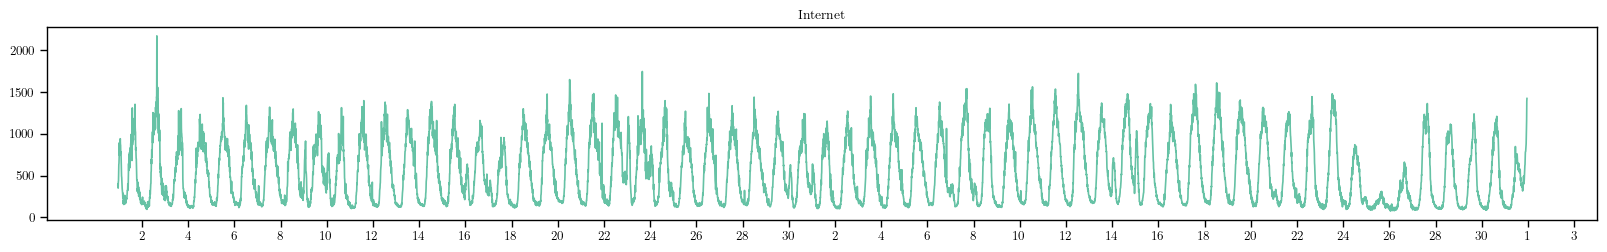

In [97]:
plt.figure(figsize=(20,2.5))
plt.title("Internet")
plt.plot(pd.to_datetime(df["time"],unit="ms"),df["internet"],color='C0')
plt.xticks([(datetime.datetime(2013,11,1)+datetime.timedelta(days=i)) for i in range(1,64,2)],[(datetime.datetime(2013,11,1)+datetime.timedelta(days=i)).day for i in range(1,64,2)])
plt.show()

In [98]:
def create_sequence(data, time_steps, horizon_steps):
    X, y = [], []
    for i in range(len(data) - time_steps - horizon_steps):
        X.append(np.array(data[i:i+time_steps]))
        y.append(np.array(data[i+time_steps:i+time_steps+horizon_steps]))
    return np.array(X), np.array(y)

def load_and_preprocess_data(data_path, cell_id, features, time_steps, horizon_steps, train_perc=0.8, val_perc=0.9):
    df_train=pd.read_csv(os.path.join("training-data",f"train-{cell_id}.csv"))
    df_val=pd.read_csv(os.path.join("training-data",f"val-{cell_id}.csv"))
    df_test=pd.read_csv(os.path.join("training-data",f"test-{cell_id}.csv"))
    
    scaler = MinMaxScaler()
    scaler.fit(df_train[features])
    
    df_train_scaled = pd.DataFrame(scaler.transform(df_train[features]), columns=features)
    df_val_scaled = pd.DataFrame(scaler.transform(df_val[features]), columns=features)
    df_test_scaled = pd.DataFrame(scaler.transform(df_test[features]), columns=features)
    
    X_train, y_train = create_sequence(df_train_scaled.values, time_steps, horizon_steps)
    X_val, y_val = create_sequence(df_val_scaled.values, time_steps, horizon_steps)
    X_test, y_test = create_sequence(df_test_scaled.values, time_steps, horizon_steps)
    
    return (X_train, y_train), (X_val, y_val), (X_test, y_test), scaler

print("=== Loading and preprocessing data ===")
features = ["internet"] # Default from notebook
(X_train, y_train), (X_val, y_val), (X_test, y_test), scaler = load_and_preprocess_data(
    "clean-data", cell_id, features, time_steps, horizon
)
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")

=== Loading and preprocessing data ===
X_train shape: (7012, 12, 1)
y_train shape: (7012, 3, 1)


In [99]:
# loading models
model=load_model(os.path.join("models",fg_model_name))

In [103]:
prediction=model.predict(X_test)
baseline_prediction=(X_test[:,-1]*np.array([1,1,1])).reshape((-1,horizon,1))

print(X_test[:2])
print("hello")
# print(baseline_prediction[:2])

 2/27 ━━━━━━━━━━━━━━━━━━━━ 1s 57ms/step

/home/default/venv-plot/lib/python3.12/site-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


27/27 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step
[[[0.01993684]
  [0.02290553]
  [0.02700656]
  [0.03302683]
  [0.02088455]
  [0.02785153]
  [0.02563636]
  [0.01514163]
  [0.01498821]
  [0.02946964]
  [0.0186991 ]
  [0.02529061]]

 [[0.02290553]
  [0.02700656]
  [0.03302683]
  [0.02088455]
  [0.02785153]
  [0.02563636]
  [0.01514163]
  [0.01498821]
  [0.02946964]
  [0.0186991 ]
  [0.02529061]
  [0.01928517]]]
hello


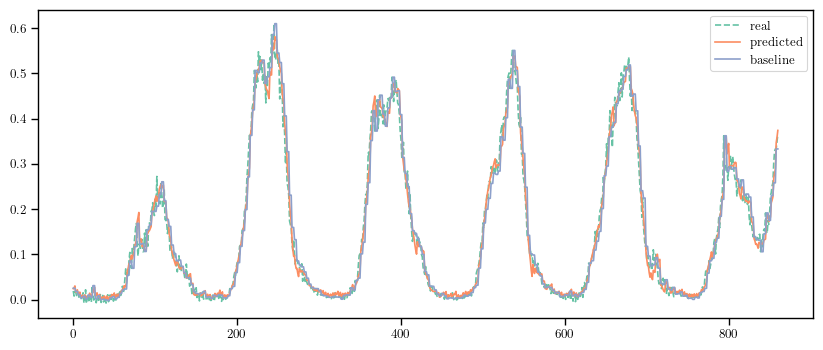

=== Baseline==============================================================
RMSE step 0: 44.94789458786861
RMSE step 1: 57.8876705947678
RMSE step 2: 73.60885253671945
=== Fine-Grained Model====================================================
RMSE step 0: 39.34117135934479
RMSE step 1: 46.945539979483776
RMSE step 2: 56.71509129526698


In [104]:
# plt.figure(figsize=(10,4))
# plt.plot(np.arange(0,len(y_test),1),y_test[:,0,0],label="Real",color="C0",linestyle="--")
# plt.plot(np.arange(0,len(y_test),1),prediction[:,0],label="Fine-Grained",color="C1")
# plt.plot(np.arange(0,len(y_test),1),baseline_prediction[:,0],label="Baseline",color="C2")
# plt.legend()
# plt.show()


prediction_sampled=[]
baseline_prediction_sampled=[]
i=0
while i<len(y_test)-horizon:
    prediction_sampled.extend(prediction[i].flatten().tolist())
    baseline_prediction_sampled.extend(baseline_prediction[i].flatten().tolist())
    i+=horizon
prediction_sampled=np.array(prediction_sampled).reshape((-1,1))
baseline_prediction_sampled=np.array(baseline_prediction_sampled).reshape((-1,1))
len_sampled=len(prediction_sampled)

plt.figure(figsize=(10,4))
plt.plot(np.arange(0,len_sampled,1),y_test[:len_sampled,0,0],label="real",color="C0",linestyle="--")
plt.plot(np.arange(0,len_sampled,1),prediction_sampled[:,0],label="predicted",color="C1")
plt.plot(np.arange(0,len_sampled,1),baseline_prediction_sampled[:,0],label="baseline",color="C2")
plt.legend()
plt.savefig(os.path.join("plots","lstm-vs-baseline-sampled.pdf"), format='pdf')
plt.savefig(os.path.join("plots","lstm-vs-baseline-sampled.png"), format='png', dpi=150)
plt.show()

print("=== Baseline==============================================================")
for i in range(horizon):
    test_unscaled=scaler.inverse_transform(y_test[:,i])
    prediction_unscaled=scaler.inverse_transform(baseline_prediction[:,i])
    print(f"RMSE step {i}: {root_mean_squared_error(test_unscaled[:,0],prediction_unscaled[:,0])}")

print("=== Fine-Grained Model====================================================")
for i in range(horizon):
    test_unscaled=scaler.inverse_transform(y_test[:,i])
    prediction_unscaled=scaler.inverse_transform(prediction[:,i])
    print(f"RMSE step {i}: {root_mean_squared_error(test_unscaled[:,0],prediction_unscaled[:,0])}")